In [1]:
from dataset import CUB

dataset = CUB('/home/asenella/scratch/data/', split='eval', one_hot=False)

In [2]:
dataset.text_data.vocab_size

1590

In [5]:
dataset[1].data['text']['tokens']


tensor([ 15,   5,  45,  51,  10,   4,  59,  60,   6,   3,  46,   7,  13,  10,
          7, 126, 143,  14,   2,   1,   1,   1,   1,   1,   1,   1,   1,   1,
          1,   1,   1,   1])

In [6]:
from multivae.models.nn.cub import CubTextEncoder
from multivae.models import JNFGMC, JNFGMCConfig

model_config = JNFGMCConfig(
    n_modalities = 2,
    latent_dim = 64
)

encoder = CubTextEncoder(
    model_config, 
    max_sentence_length=32,
    ntokens=dataset.text_data.vocab_size,
    embed_size=512
)



In [7]:
from torch.utils.data import DataLoader

dl = DataLoader(dataset,10)

sample = next(iter(dl))

sample = sample.data['text']

sample


{'tokens': tensor([[  3, 161, 338,   5,   6,   3,  20,  43,  45, 976,  33, 345,  32,  28,
           50,  21,  43,  16,   3, 437,  78,  10,  50,  21,   7,  10,   4,  37,
           21,  10,   3,   2],
         [ 15,   5,  45,  51,  10,   4,  59,  60,   6,   3,  46,   7,  13,  10,
            7, 126, 143,  14,   2,   1,   1,   1,   1,   1,   1,   1,   1,   1,
            1,   1,   1,   1],
         [  5,   6,   3, 161,  35,  21, 450,  50,  21,  80,  22,  42,  10,   7,
           53,  42,  14,   2,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
            1,   1,   1,   1],
         [ 15,  45,   3,  12,   5,   6,  72,  63,  10,   3,   7,  35,  14,   2,
            1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
            1,   1,   1,   1],
         [  3, 161,   5,   6,   3,   4,  22,  21,  34,  10, 251,  21,   7, 159,
           21,  85,  21,  10,  36,  14,   2,   1,   1,   1,   1,   1,   1,   1,
            1,   1,   1,   1],
         [180, 344,   4,  50,   5, 

In [8]:
embedding = encoder(sample)
embedding.embedding.shape

torch.Size([10, 64])

In [9]:
from multivae.models.nn.cub import CubTextDecoderMLP
from pythae.models.base import BaseAEConfig

decoder = CubTextDecoderMLP(
        BaseAEConfig(
            latent_dim=model_config.latent_dim,
            input_dim=(1590, 32),
        ))

In [10]:
decoder(embedding.embedding)

ModelOutput([('reconstruction',
              tensor([[[-0.1059, -0.1495,  0.3390,  ..., -0.0629,  0.1538, -0.0729],
                       [ 0.0056,  0.1802,  0.0804,  ..., -0.0316,  0.0275,  0.0084],
                       [-0.1124, -0.2833, -0.1580,  ..., -0.0920,  0.0846, -0.1103],
                       ...,
                       [-0.0158, -0.0477,  0.0922,  ...,  0.1223,  0.0527,  0.1322],
                       [-0.1028, -0.0044, -0.0522,  ..., -0.1481,  0.0751, -0.0102],
                       [-0.0205,  0.0632, -0.0919,  ..., -0.1035,  0.1326,  0.0385]],
              
                      [[-0.1888, -0.0487,  0.0465,  ..., -0.0436,  0.1195, -0.0651],
                       [-0.1844,  0.1850,  0.1681,  ..., -0.3099,  0.0231,  0.1408],
                       [-0.3384, -0.0328,  0.0893,  ..., -0.0897, -0.0698,  0.1856],
                       ...,
                       [-0.1156, -0.1523,  0.0969,  ...,  0.2554, -0.0327,  0.0733],
                       [-0.1496, -0.1052, -0.2

In [26]:

from architectures_image import EncoderImg, DecoderImg

encoder_image = EncoderImg(0,12,'normal')

embedding = encoder_image(dataset[0].data['image'].unsqueeze(0))

embedding.embedding.shape

torch.Size([1, 12])

In [27]:
decoder_image = DecoderImg(12)

decoder_image(joint_embedding)

ModelOutput([('reconstruction',
              tensor([[[[ 0.0289,  0.0259,  0.0253,  ..., -0.0060, -0.0054,  0.0033],
                        [ 0.0108,  0.0013,  0.0010,  ...,  0.0010,  0.0013,  0.0113],
                        [ 0.0107,  0.0010,  0.0006,  ...,  0.0010,  0.0014,  0.0114],
                        ...,
                        [ 0.0260,  0.0007,  0.0009,  ...,  0.0335,  0.0343,  0.0432],
                        [ 0.0261,  0.0006,  0.0012,  ...,  0.0333,  0.0341,  0.0433],
                        [ 0.0246,  0.0063,  0.0067,  ...,  0.0581,  0.0585,  0.0600]],
              
                       [[ 0.0497,  0.0528,  0.0533,  ...,  0.0428,  0.0431,  0.0492],
                        [ 0.0734,  0.0666,  0.0669,  ...,  0.0686,  0.0690,  0.0695],
                        [ 0.0737,  0.0670,  0.0674,  ...,  0.0685,  0.0689,  0.0696],
                        ...,
                        [ 0.0491,  0.0449,  0.0450,  ...,  0.0709,  0.0712,  0.0573],
                        [ 0.0486, 

In [28]:
from multivae.models import JNF, JNFConfig

model_config = JNFConfig(
    n_modalities = 2,
    latent_dim = 12,
    decoders_dist=dict(image = 'laplace',text = 'categorical'),
    warmup=10
)


model=JNF(model_config=model_config,
                encoders = dict(image = EncoderImg(0,model_config.latent_dim,dist='normal'),
                                text = Enc(0,model_config.latent_dim,dist='normal')),
                
                decoders=dict(
                    image = DecoderImg(model_config.latent_dim),
                    text = Dec(0,model_config.latent_dim)
                )
                
                )




In [29]:
from torch.utils.data import DataLoader

dataloader = DataLoader(dataset,batch_size=32)

sample = next(iter(dataloader))

model(sample)

ModelOutput([('loss', tensor(14116.8066, grad_fn=<DivBackward0>)),
             ('metrics',
              {'kld_prior': tensor(0.5615, grad_fn=<MulBackward0>),
               'recon_loss': tensor(14116.7891, grad_fn=<DivBackward0>),
               'ljm': 0})])

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import PIL

def plot_text(input_tensor, fig_size=(1.5,2)):
        # input_tensor is of shape (max_sequence_lenght,vocab_size)
        array = input_tensor.detach().numpy()
        sentence = dataset.text_data._to_string(array)
        
        fig = plt.figure(figsize=fig_size)
        plt.text(
            x=0.5,
            y=0.5,
            s='{}'.format(
                ' '.join(i + '\n' if (n + 1) % 3 == 0
                         else i for n, i in enumerate([word for word in sentence.split() if word != '<eos>']))),
            fontsize=7,
            verticalalignment='center_baseline',
            horizontalalignment='center'
        )
        plt.axis('off')
        fig.tight_layout()
        print(fig.canvas.get_width_height())
        # Draw the canvas and retrieve the image as a NumPy array
        fig.canvas.draw()
        image = PIL.Image.frombytes('RGB', 
                    fig.canvas.get_width_height(),fig.canvas.tostring_rgb())
        
        image= np.array(image).transpose(2,0,1)/255
        
        return torch.from_numpy(image).float()

(150, 200)


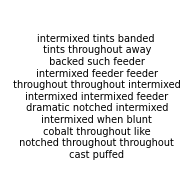

In [31]:

r = recon.reconstruction.squeeze()
numpimage = plot_text(r)


In [32]:
numpimage

tensor([[[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]]])

In [33]:
from PIL import Image

ndarr = (
                numpimage.mul(255)
                .add_(0.5)
                .clamp_(0, 255)
                .permute(1, 2, 0)
                .to("cpu", torch.uint8)
                .numpy()
            )
recon_image = Image.fromarray(ndarr)
            
            


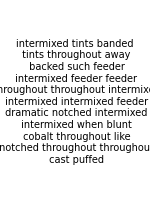

In [34]:
recon_image

Model passed sanity check !
Ready for training.

Setting the optimizer with learning rate 0.0001
Created dummy_output_dir/JNF_training_2024-09-13_13-33-43. 
Training config, checkpoints and final model will be saved here.



(200, 150)
(200, 150)
(200, 150)


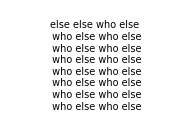

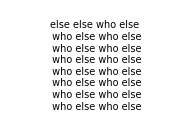

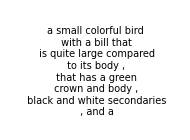

In [35]:
from multivae.trainers import BaseTrainer, BaseTrainerConfig

trainer_config = BaseTrainerConfig(num_epochs=2,
)

trainer = BaseTrainer(
    model = model,
    train_dataset=dataset,
    eval_dataset=dataset,
    training_config=trainer_config
)

a = trainer.predict(model,1, n_data=1)

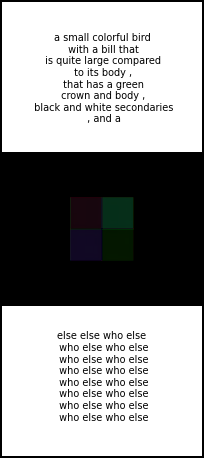

In [38]:
a['text']

In [37]:
8*104 + 9*104

1768

In [2]:
import torch 
import torch.distributions as dist


In [7]:
t = torch.randn(4 * 3 * 5*6).reshape(4,3,5,6)

In [21]:
inputs = torch.nn.functional.one_hot( torch.max(torch.randn((3,5,6)),dim=-1)[-1])
inputs

tensor([[[0, 0, 0, 1, 0, 0],
         [0, 0, 0, 0, 1, 0],
         [0, 1, 0, 0, 0, 0],
         [0, 0, 1, 0, 0, 0],
         [0, 1, 0, 0, 0, 0]],

        [[0, 0, 1, 0, 0, 0],
         [0, 0, 0, 0, 1, 0],
         [0, 0, 0, 0, 1, 0],
         [0, 0, 0, 0, 1, 0],
         [0, 0, 0, 0, 1, 0]],

        [[0, 0, 0, 0, 0, 1],
         [1, 0, 0, 0, 0, 0],
         [0, 0, 0, 1, 0, 0],
         [0, 0, 0, 1, 0, 0],
         [0, 0, 1, 0, 0, 0]]])

In [23]:
d = dist.OneHotCategorical(torch.softmax(t, dim=-1))

d.log_prob(inputs).sum()

tensor(-118.0113)

In [26]:
from torch.nn import functional as F

def cross_entropy(input, target, eps=1e-6):
    """k-Class Cross Entropy (Log Softmax + Log Loss)

    @param input: torch.Tensor (size K x N x d)
    @param target: torch.Tensor (size N x d) or (d,)
    @param eps: error to add (default: 1e-6)
    @return loss: torch.Tensor (size N)
    """
    if isinstance(target, dict):
        # converts to tokens proba instead of class id for text
        _target = torch.zeros(input.shape[0] * input.shape[1], input.shape[-1]).to(
            input.device
        )
        _target = _target.scatter(1, target["tokens"].reshape(-1, 1), 1)
        input = input.reshape(input.shape[0] * input.shape[1], -1)
    else:
        _target = target

    log_input = F.log_softmax(input + eps, dim=-1)
    loss = _target * log_input
    return loss


cross_entropy(t,inputs).sum()

tensor(-118.0113)